# CHAPTER 3 — Data Description & Exploratory Analysis  
======================================================  
Purpose: produce the tables/graphs for your dissertation's Data Description  
chapter. Built from Step 1's saved outputs — no EDW re-auth needed, this  
runs entirely off local parquet files.  
  
Incorporates supervisor guidance (Jack Denham, 3 Aug 2026 meeting) plus  
standard professional EDA practice for a chapter of this kind:  
  
  Jack's specific suggestions:  
    - "a bar chart of top transactions by support... this drug with this  
      product, 10% of the entire transactional database... 8%, 6%"  
      -> Section 3.8 (top individual products by frequency)  
    - "accumulate over product type or drug type, like cardiac drugs...  
      find some cool ways to group them"  
      -> Section 3.6 (BNF chapter/category breakdown)  
  
  Added on top, as standard practice for a Chapter 3 of this kind:  
    - Data cleaning funnel (Section 3.2) — shows the reader exactly how the  
      cohort was built and what was excluded at each stage, which is  
      normally expected in a methodology-adjacent data chapter  
    - Demographics (3.3), temporal coverage (3.4), basket-size distribution  
      (3.5) — the last one directly justifies your MIN_SUPPORT choice in  
      Chapter 4, so it earns its place here rather than being decorative  
    - Legal category (OTC vs POM) split (3.7) — this is where you report,  
      with a real number, the structural limitation we found empirically:  
      the dispense data is overwhelmingly POM. That's a finding worth  
      stating plainly in a dissertation, not something to hide.  
  
Each section prints a table and/or saves a figure to ./chapter3_figures/,  
sized and captioned for direct use in a Word/LaTeX document.


No EDW authentication needed for most of this notebook — it runs off Step 1's saved parquet files. Section 3.6 optionally re-authenticates only if you want readable BNF chapter *names* instead of raw codes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

FIG_DIR = Path("chapter3_figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300           # print-quality for the write-up
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### 3.0 — Load Step 1's outputs

In [2]:
transactions = pd.read_parquet("clean_transactions_all_drugs.parquet")
otc_products = pd.read_parquet("otc_product_universe.parquet")
cohort = pd.read_parquet("clean_cohort_all.parquet")

transactions["dispense_date_created"] = pd.to_datetime(transactions["dispense_date_created"])

print(f"Loaded: {len(transactions):,} transaction lines | "
      f"{len(otc_products):,} OTC-eligible products | "
      f"{len(cohort):,} cohort customers")

Loaded: 67,124,000 transaction lines | 3,619 OTC-eligible products | 1,916,955 cohort customers


### 3.1 — Dataset overview summary table

In [3]:
overview = pd.DataFrame({
    "Metric": [
        "Transaction rows (dispensed items)",
        "Unique customers",
        "Unique products dispensed",
        "OTC-eligible products in catalogue",
        "Date range covered",
        "Median transactions per customer",
    ],
    "Value": [
        f"{len(transactions):,}",
        f"{transactions['CustomerKey'].nunique():,}",
        f"{transactions['ProductKey'].nunique():,}",
        f"{len(otc_products):,}",
        f"{transactions['dispense_date_created'].min().date()} to "
        f"{transactions['dispense_date_created'].max().date()}",
        f"{transactions.groupby('CustomerKey').size().median():.0f}",
    ],
})
print("\n=== Table 3.1: Dataset Overview ===")
print(overview.to_string(index=False))
overview.to_csv(FIG_DIR / "table_3_1_dataset_overview.csv", index=False)


=== Table 3.1: Dataset Overview ===
                            Metric                    Value
Transaction rows (dispensed items)               67,124,000
                  Unique customers                1,872,959
         Unique products dispensed                   22,569
OTC-eligible products in catalogue                    3,619
                Date range covered 2024-01-01 to 2025-12-31
  Median transactions per customer                       17


### 3.2 — Data cleaning funnel


=== Table 3.2: Data Cleaning Funnel (fill in blanks from Step 1 output) ===
                                Stage  Row / Customer Count
Raw prescription items in date window                   NaN
  Candidate customers before cleaning                   NaN
After deceased/deregistered exclusion             1916955.0
         Final clean transaction rows            67124000.0


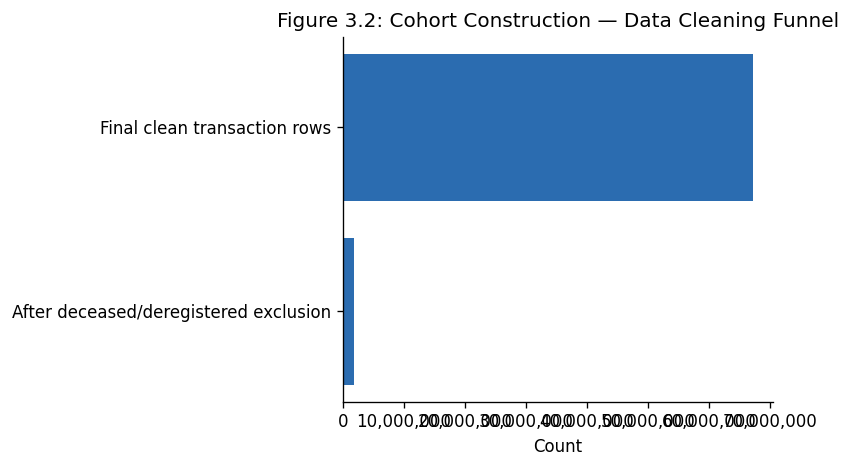

In [4]:
# Fill in the row counts your Step 1 notebook printed at each [A]-[D] stage.
# This documents exactly what was excluded and why — standard practice for
# a methodology-adjacent data chapter, and it pre-empts the obvious
# reviewer question "why did your cohort shrink from X to Y?"
cleaning_funnel = pd.DataFrame({
    "Stage": [
        "Raw prescription items in date window",
        "Candidate customers before cleaning",
        "After deceased/deregistered exclusion",
        "Final clean transaction rows",
    ],
    # Fill these in from your actual Step 1 [A]-[D] printed output —
    # placeholders shown below, replace with your real numbers
    "Row / Customer Count": [np.nan, np.nan, len(cohort), len(transactions)],
})
print("\n=== Table 3.2: Data Cleaning Funnel (fill in blanks from Step 1 output) ===")
print(cleaning_funnel.to_string(index=False))
cleaning_funnel.to_csv(FIG_DIR / "table_3_2_cleaning_funnel.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
funnel_plot = cleaning_funnel.dropna()
ax.barh(funnel_plot["Stage"], funnel_plot["Row / Customer Count"], color="#2b6cb0")
ax.set_xlabel("Count")
ax.set_title("Figure 3.2: Cohort Construction — Data Cleaning Funnel")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_2_cleaning_funnel.png")
plt.show()

### 3.3 — Customer demographics

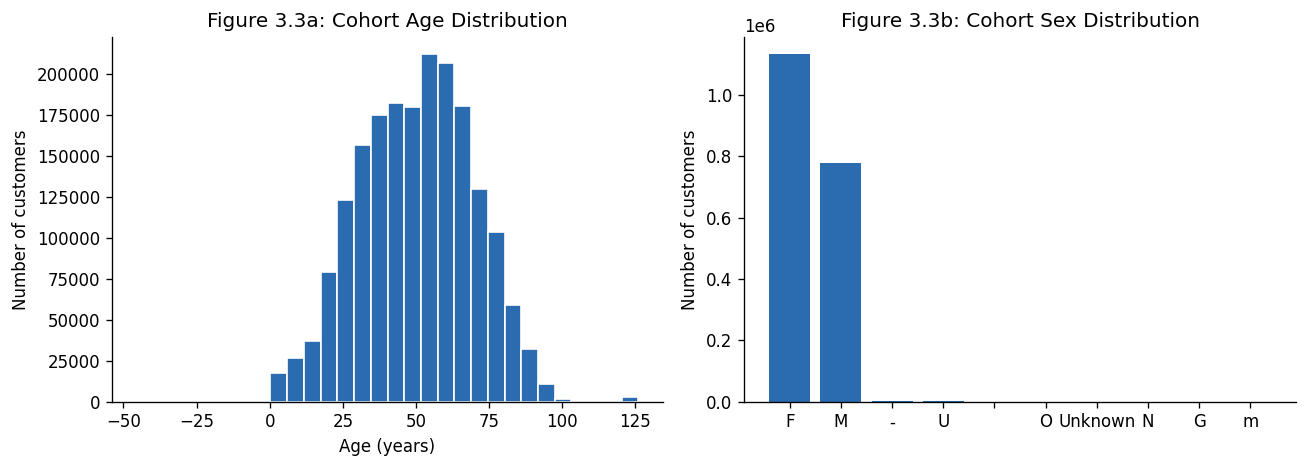


=== Table 3.3: Age summary statistics ===
count    1.916482e+06
mean     5.024532e+01
std      1.941418e+01
min     -4.547844e+01
25%      3.579740e+01
50%      5.110198e+01
75%      6.430938e+01
max      1.259959e+02


In [5]:
cohort["CustomerDateOfBirth"] = pd.to_datetime(cohort["CustomerDateOfBirth"], errors="coerce")
snapshot = transactions["dispense_date_created"].max()
cohort["age_years"] = (snapshot - cohort["CustomerDateOfBirth"]).dt.days / 365.25

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(cohort["age_years"].dropna(), bins=30, color="#2b6cb0", edgecolor="white")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Number of customers")
axes[0].set_title("Figure 3.3a: Cohort Age Distribution")

gender_counts = cohort["CustomerSex"].fillna("Unknown").value_counts()
axes[1].bar(gender_counts.index.astype(str), gender_counts.values, color="#2b6cb0")
axes[1].set_ylabel("Number of customers")
axes[1].set_title("Figure 3.3b: Cohort Sex Distribution")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_3_demographics.png")
plt.show()

print("\n=== Table 3.3: Age summary statistics ===")
print(cohort["age_years"].describe().to_string())

### 3.4 — Temporal distribution of transactions

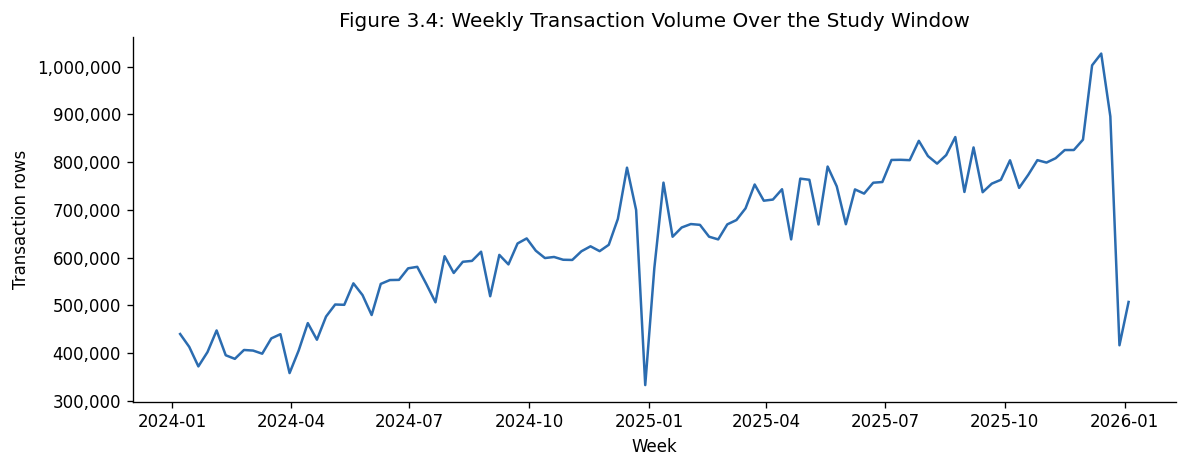

In [6]:
weekly_volume = (
    transactions
    .set_index("dispense_date_created")
    .resample("W")
    .size()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekly_volume.index, weekly_volume.values, color="#2b6cb0", linewidth=1.5)
ax.set_xlabel("Week")
ax.set_ylabel("Transaction rows")
ax.set_title("Figure 3.4: Weekly Transaction Volume Over the Study Window")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_4_weekly_volume.png")
plt.show()

### 3.5 — Basket size distribution (directly justifies MIN_SUPPORT in Ch.4)

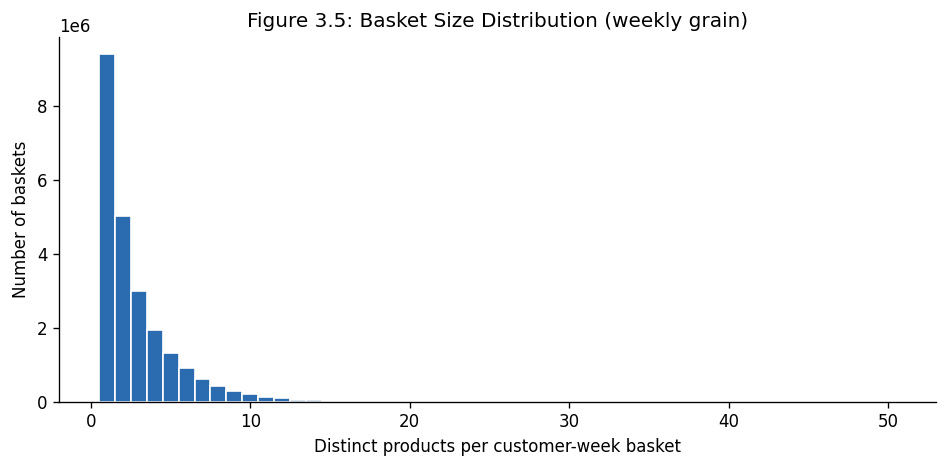


=== Table 3.5: Basket size summary ===
count    2.346415e+07
mean     2.785298e+00
std      2.421294e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      5.000000e+01

Baskets with >= 2 items (usable for FP-Growth): 14,068,537 / 23,464,150 (60.0%)


In [7]:
transactions["_week"] = transactions["dispense_date_created"].dt.to_period("W").dt.start_time
basket_sizes = (
    transactions.groupby(["CustomerKey", "_week"])["ProductKey"]
    .nunique()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(basket_sizes, bins=range(1, basket_sizes.max() + 2), color="#2b6cb0",
        edgecolor="white", align="left")
ax.set_xlabel("Distinct products per customer-week basket")
ax.set_ylabel("Number of baskets")
ax.set_title("Figure 3.5: Basket Size Distribution (weekly grain)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_5_basket_size_distribution.png")
plt.show()

print("\n=== Table 3.5: Basket size summary ===")
print(basket_sizes.describe().to_string())
print(f"\nBaskets with >= 2 items (usable for FP-Growth): "
      f"{(basket_sizes >= 2).sum():,} / {len(basket_sizes):,} "
      f"({(basket_sizes >= 2).mean():.1%})")

### 3.6 — Drug category breakdown (BNF chapter) — Jack: "accumulate over product type or drug type, like cardiac drugs... find cool ways to group them"

In [8]:
# ProductCodeLevel1 (BNF chapter, 2-char) is already attached to
# `transactions` from Step 1. For readable chapter NAMES rather than raw
# codes, optionally pull Dim.BNFHierarchy (tiny, 519 rows, not Tier-A) — a
# few extra lines, worth it for a dissertation-quality chart.
#
# If you don't want to re-authenticate to the EDW just for this, the chart
# still works on raw chapter codes — just skip the next cell and the merge
# below will leave BNF_Chapter_Name as NaN, falling back to the code itself.

try:
    from edw_helpers import authenticate, load_table_smart
    authenticate()
    bnf_hier = load_table_smart(
        "Dim_BNFHierarchy", columns=["Chapter", "Depth", "Description"]
    )
    bnf_chapter_names = (
        bnf_hier[bnf_hier["Depth"] == 1][["Chapter", "Description"]]
        .rename(columns={"Chapter": "ProductCodeLevel1", "Description": "BNF_Chapter_Name"})
    )
    have_bnf_names = True
except Exception as e:
    print(f"Skipping BNF chapter name lookup ({e}) — will plot raw chapter codes instead")
    bnf_chapter_names = None
    have_bnf_names = False

category_counts = (
    transactions.groupby("ProductCodeLevel1")
    .size()
    .reset_index(name="transaction_count")
    .sort_values("transaction_count", ascending=False)
)

if have_bnf_names:
    category_counts = category_counts.merge(bnf_chapter_names, on="ProductCodeLevel1", how="left")
    category_counts["label"] = category_counts["BNF_Chapter_Name"].fillna(
        category_counts["ProductCodeLevel1"]
    )
else:
    category_counts["label"] = category_counts["ProductCodeLevel1"]

top_categories = category_counts.head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_categories["label"][::-1], top_categories["transaction_count"][::-1], color="#2b6cb0")
ax.set_xlabel("Transaction count")
ax.set_title("Figure 3.6: Top 15 Drug Categories by Transaction Volume (BNF Chapter)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_6_bnf_chapter_breakdown.png")
plt.show()

print("\n=== Table 3.6: Drug category breakdown (top 15) ===")
print(top_categories[["label", "transaction_count"]].to_string(index=False))

Stage A  DeviceCodeCredential created
To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code CD3YGQ3F6 to authenticate.


### 3.7 — Legal category split (OTC vs POM) — reports the structural limitation found empirically: this table is the evidence for that claim.

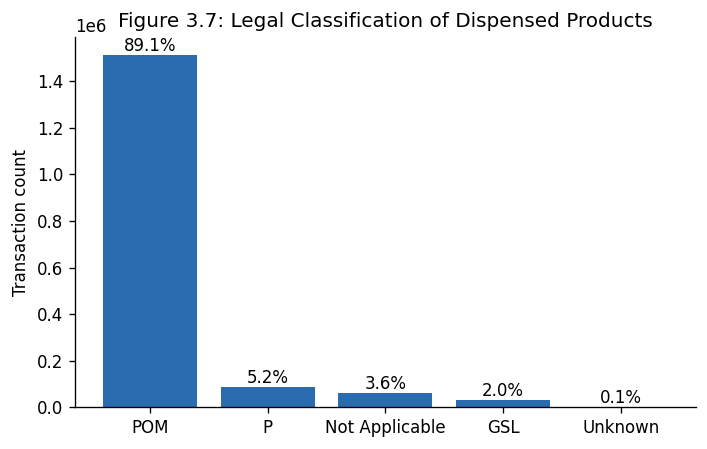


=== Table 3.7: Legal category split ===
                  Count  Percent
LEGAL_CAT                       
POM             1513511    89.14
P                 88851     5.23
Not Applicable    60896     3.59
GSL               33417     1.97
Unknown            1145     0.07

Note for write-up: the near-total dominance of POM here is a genuine structural finding, not a data-quality issue — NHS prescribing guidance actively discourages GPs from prescribing products that are available over the counter, so OTC-classified drugs rarely appear in NHS dispense records even though they are not legally barred from it.


In [9]:
legal_cat_counts = transactions["LEGAL_CAT"].fillna("Unknown").value_counts()
legal_cat_pct = (legal_cat_counts / legal_cat_counts.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(legal_cat_counts.index.astype(str), legal_cat_counts.values, color="#2b6cb0")
ax.set_ylabel("Transaction count")
ax.set_title("Figure 3.7: Legal Classification of Dispensed Products")
for i, (cat, cnt) in enumerate(legal_cat_counts.items()):
    ax.text(i, cnt, f"{legal_cat_pct[cat]:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_7_legal_category_split.png")
plt.show()

print("\n=== Table 3.7: Legal category split ===")
print(pd.DataFrame({"Count": legal_cat_counts, "Percent": legal_cat_pct}).to_string())
print(
    "\nNote for write-up: the near-total dominance of POM here is a genuine "
    "structural finding, not a data-quality issue — NHS prescribing "
    "guidance actively discourages GPs from prescribing products that are "
    "available over the counter, so OTC-classified drugs rarely appear in "
    "NHS dispense records even though they are not legally barred from it."
)

### 3.8 — Top individual products by frequency (Jack's suggested chart: "top transactions by support... this drug... 10%... 8%... 6%")

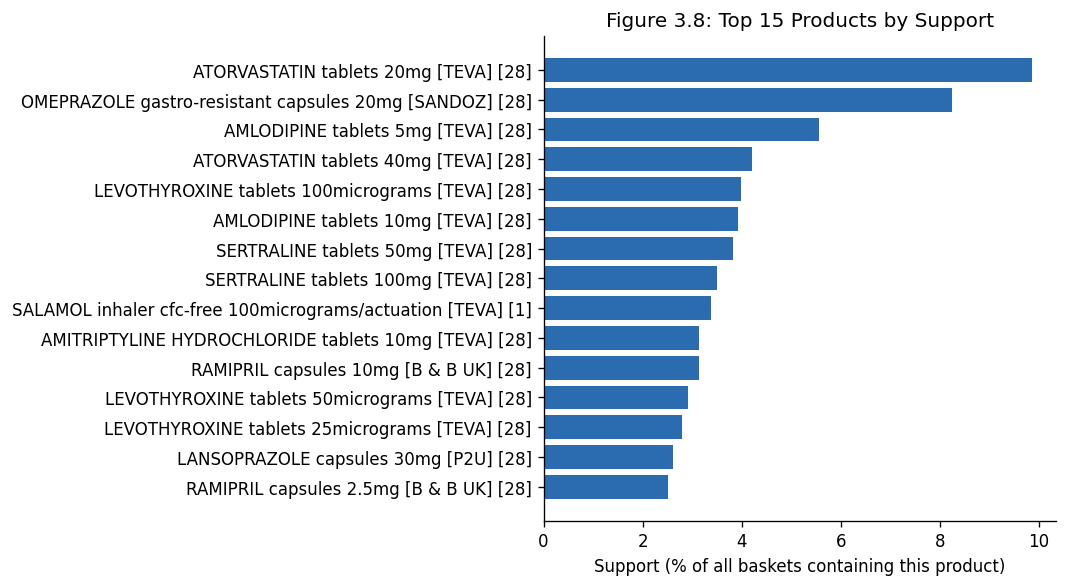


=== Table 3.8: Top 15 products by support ===
                                                   DrugName  basket_count  support_pct
                      ATORVASTATIN tablets 20mg [TEVA] [28]         58651     9.854677
    OMEPRAZOLE gastro-resistant capsules 20mg [SANDOZ] [28]         49052     8.241831
                         AMLODIPINE tablets 5mg [TEVA] [28]         33117     5.564395
                      ATORVASTATIN tablets 40mg [TEVA] [28]         25018     4.203583
            LEVOTHYROXINE tablets 100micrograms [TEVA] [28]         23673     3.977593
                        AMLODIPINE tablets 10mg [TEVA] [28]         23342     3.921977
                        SERTRALINE tablets 50mg [TEVA] [28]         22765     3.825028
                       SERTRALINE tablets 100mg [TEVA] [28]         20825     3.499065
SALAMOL inhaler cfc-free 100micrograms/actuation [TEVA] [1]         20170     3.389010
       AMITRIPTYLINE HYDROCHLORIDE tablets 10mg [TEVA] [28]         18708     3.143

In [10]:
n_baskets_total = transactions.groupby(["CustomerKey", "_week"]).ngroups

product_support = (
    transactions.drop_duplicates(subset=["CustomerKey", "_week", "ProductKey"])
    .groupby(["ProductKey", "DrugName"])
    .size()
    .reset_index(name="basket_count")
)
product_support["support_pct"] = product_support["basket_count"] / n_baskets_total * 100
product_support = product_support.sort_values("support_pct", ascending=False)

top_products = product_support.head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_products["DrugName"][::-1], top_products["support_pct"][::-1], color="#2b6cb0")
ax.set_xlabel("Support (% of all baskets containing this product)")
ax.set_title("Figure 3.8: Top 15 Products by Support")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_8_top_products_by_support.png")
plt.show()

print("\n=== Table 3.8: Top 15 products by support ===")
print(top_products[["DrugName", "basket_count", "support_pct"]].to_string(index=False))

print(f"\nAll Chapter 3 tables and figures saved to: {FIG_DIR.resolve()}")